In [26]:

# ✔ Data loading
# ✔ Data cleaning
# ✔ Missing value handling
# ✔ Duplicate removal
# ✔ Feature engineering
# ✔ Exploratory data analysis
# ✔ Correlation analysis
# ✔ Data visualization


In [1]:
import os
os.mkdir("data")

In [2]:
## download_data.py

In [3]:
import yfinance as yf
import pandas as pd

ticker = "AAPL"

df = yf.download(
    ticker,
    start="2023-01-01",
    end="2025-01-01",
    auto_adjust=False
)

# Flatten MultiIndex columns
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Convert index to a Date column
df = df.reset_index()

print(df.columns)
print(df.head())

[*********************100%***********************]  1 of 1 completed

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Price       Date   Adj Close       Close        High         Low        Open  \
0     2023-01-03  122.982704  125.070000  130.899994  124.169998  130.279999   
1     2023-01-04  124.251198  126.360001  128.660004  125.080002  126.889999   
2     2023-01-05  122.933540  125.019997  127.769997  124.760002  127.129997   
3     2023-01-06  127.456802  129.619995  130.289993  124.889999  126.010002   
4     2023-01-09  127.977959  130.149994  133.410004  129.889999  130.470001   

Price     Volume  
0      112117500  
1       89113600  
2       80962700  
3       87754700  
4       70790800  


In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

In [ ]:
# Convert the index to datetime
df.index = pd.to_datetime(df.index)

# Sort by date
df = df.sort_index()

In [6]:
df.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [7]:
# Convert index to a column
df = df.reset_index()

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort by Date
df = df.sort_values("Date")

print(df.head())

Price                         index       Date   Adj Close       Close  \
0     1970-01-01 00:00:00.000000000 2023-01-03  122.982704  125.070000   
1     1970-01-01 00:00:00.000000001 2023-01-04  124.251198  126.360001   
2     1970-01-01 00:00:00.000000002 2023-01-05  122.933540  125.019997   
3     1970-01-01 00:00:00.000000003 2023-01-06  127.456802  129.619995   
4     1970-01-01 00:00:00.000000004 2023-01-09  127.977959  130.149994   

Price        High         Low        Open     Volume  
0      130.899994  124.169998  130.279999  112117500  
1      128.660004  125.080002  126.889999   89113600  
2      127.769997  124.760002  127.129997   80962700  
3      130.289993  124.889999  126.010002   87754700  
4      133.410004  129.889999  130.470001   70790800  


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   index      502 non-null    datetime64[ns]
 1   Date       502 non-null    datetime64[ns]
 2   Adj Close  502 non-null    float64       
 3   Close      502 non-null    float64       
 4   High       502 non-null    float64       
 5   Low        502 non-null    float64       
 6   Open       502 non-null    float64       
 7   Volume     502 non-null    int64         
dtypes: datetime64[ns](2), float64(5), int64(1)
memory usage: 31.5 KB
None


In [9]:
print(df.describe())

Price                          index                           Date  \
count                            502                            502   
mean   1970-01-01 00:00:00.000000250  2024-01-01 19:56:10.517928192   
min              1970-01-01 00:00:00            2023-01-03 00:00:00   
25%    1970-01-01 00:00:00.000000125            2023-07-05 06:00:00   
50%    1970-01-01 00:00:00.000000250            2024-01-02 12:00:00   
75%    1970-01-01 00:00:00.000000375            2024-07-02 18:00:00   
max    1970-01-01 00:00:00.000000501            2024-12-31 00:00:00   
std                              NaN                            NaN   

Price   Adj Close       Close        High         Low        Open  \
count  502.000000  502.000000  502.000000  502.000000  502.000000   
mean   187.896247  189.946494  191.453745  188.167351  189.673626   
min    122.933540  125.019997  127.769997  124.169998  126.010002   
25%    169.785686  172.070007  173.554996  170.552502  171.789997   
50%    183.1350

In [10]:
df = df.ffill()

In [11]:
#Step 4: Check Duplicate Records

In [12]:

print(df.duplicated().sum())



0


In [13]:
#Remove them:

In [14]:


df = df.drop_duplicates()

In [16]:
#Step 5: Plot Closing Price

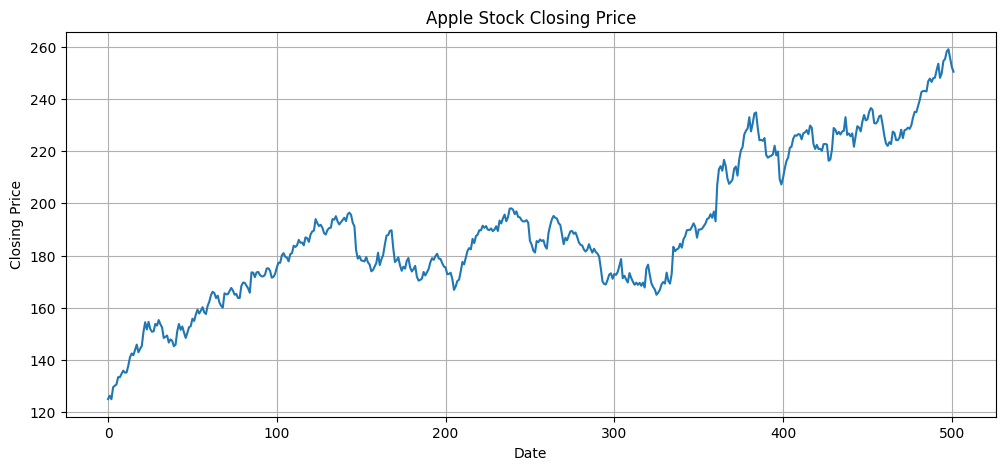

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df.index, df["Close"])

plt.title("Apple Stock Closing Price")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.grid(True)

plt.show()

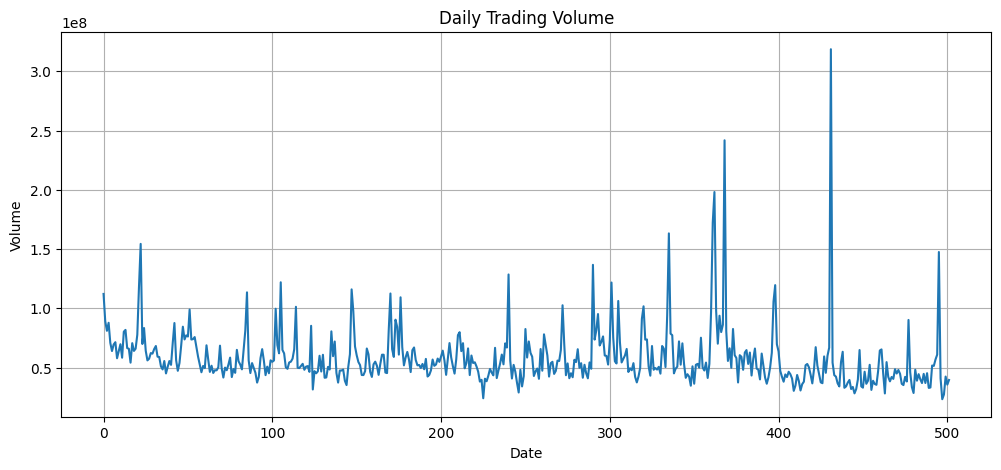

In [17]:
#Step 6: Plot Trading Volume
plt.figure(figsize=(12,5))

plt.plot(df.index, df["Volume"])

plt.title("Daily Trading Volume")

plt.xlabel("Date")

plt.ylabel("Volume")

plt.grid(True)

plt.show()

In [18]:
# Step 7: Feature Engineering
# Daily Return
df["Daily_Return"] = df["Close"].pct_change()

In [19]:
# 20-Day Moving Average
df["MA20"] = df["Close"].rolling(20).mean()

In [20]:
#50-Day Moving Average
df["MA50"] = df["Close"].rolling(50).mean()

In [21]:
#Volatility
df["Volatility"] = df["Daily_Return"].rolling(20).std()

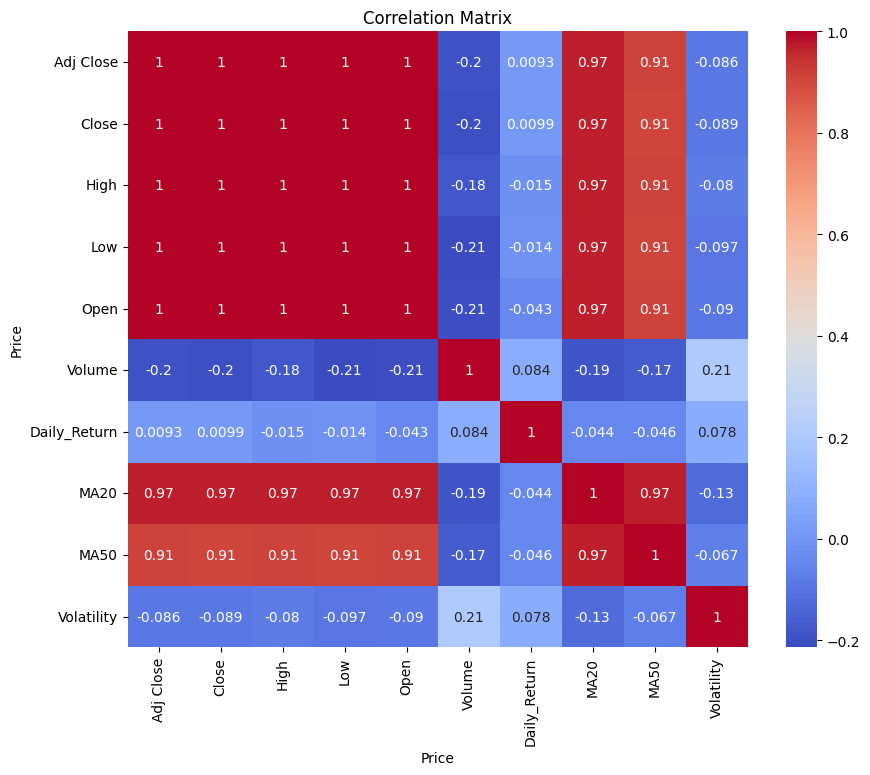

In [22]:
#Step 8: Correlation Matrix
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

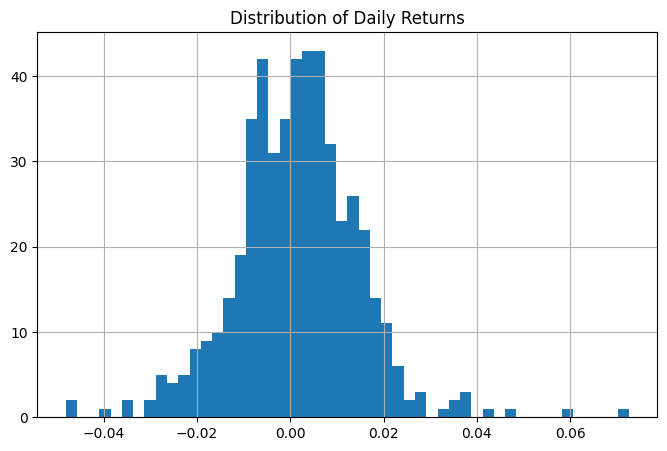

In [23]:
#Step 9: Distribution of Daily Returns
plt.figure(figsize=(8,5))

df["Daily_Return"].hist(bins=50)

plt.title("Distribution of Daily Returns")

plt.show()

In [24]:
#Step 10: Save Clean Data
df.to_csv("clean_stock_data.csv")